In [1]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
import emoji
from nltk.corpus import wordnet
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.utils import to_categorical
nltk.download('wordnet')
nltk.download('omw-1.4') 
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


### Read data

In [2]:
df = pd.read_csv("Feedback Analysis.csv", sep=",") 
df  = df[['text']]
df

,text
0,@AppleSupport causing the reply to be disregar...
1,@105835 Your business means a lot to us. Pleas...
2,@76328 I really hope you all change but I'm su...
3,@105836 LiveChat is online at the moment - htt...
4,@VirginTrains see attached error message. I've...
...,...
88,@105860 I wish Amazon had an option of where I...
89,They reschedule my shit for tomorrow https://t...
90,"@105861 Hey Sara, sorry to hear of the issues ..."
91,@Tesco bit of both - finding the layout cumber...


### Clean Data

In [3]:
def preprocess_text(text):

    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english'))
    # lowercase + remove punctuation
    text = re.sub(r'[^a-z\s]', '', text.lower())
    # tokenize
    words = text.split()
    # remove stopwords + lemmatize
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
   
    return " ".join(words)

df["Cleaned_Text"] = df["text"].apply(lambda text: preprocess_text(text))
df.head()

,text,Cleaned_Text
0,@AppleSupport causing the reply to be disregar...,applesupport causing reply disregarded tapped ...
1,@105835 Your business means a lot to us. Pleas...,business mean lot u please dm name zip code ad...
2,@76328 I really hope you all change but I'm su...,really hope change im sure wont dont
3,@105836 LiveChat is online at the moment - htt...,livechat online moment httpstcosyvtukq contact...
4,@VirginTrains see attached error message. I've...,virgintrains see attached error message ive tr...


## VADER for Sentiment Analysis

In [4]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(text)["compound"]
    
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

df["sentiment"] = df["Cleaned_Text"].apply(get_sentiment)
df

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


,text,Cleaned_Text,sentiment
0,@AppleSupport causing the reply to be disregar...,applesupport causing reply disregarded tapped ...,Negative
1,@105835 Your business means a lot to us. Pleas...,business mean lot u please dm name zip code ad...,Positive
2,@76328 I really hope you all change but I'm su...,really hope change im sure wont dont,Positive
3,@105836 LiveChat is online at the moment - htt...,livechat online moment httpstcosyvtukq contact...,Negative
4,@VirginTrains see attached error message. I've...,virgintrains see attached error message ive tr...,Negative
...,...,...,...
88,@105860 I wish Amazon had an option of where I...,wish amazon option get shipped ups store avoid...,Neutral
89,They reschedule my shit for tomorrow https://t...,reschedule shit tomorrow httpstcorsvzctt,Negative
90,"@105861 Hey Sara, sorry to hear of the issues ...",hey sara sorry hear issue ask lay speed websit...,Positive
91,@Tesco bit of both - finding the layout cumber...,tesco bit finding layout cumbersome removing i...,Positive


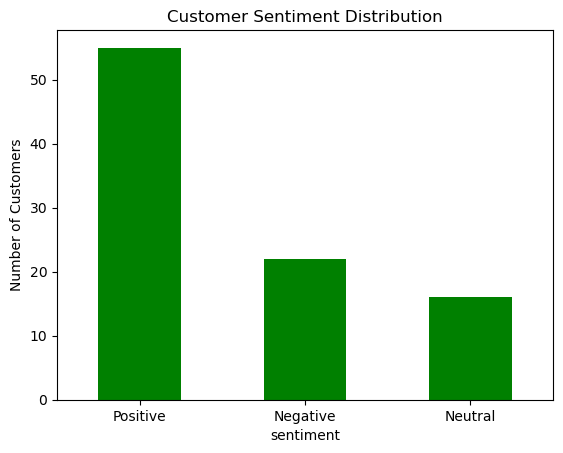

In [6]:
# Count of each category
counts = df['sentiment'].value_counts()

counts.plot(kind='bar',color='green', rot=0)
plt.title('Customer Sentiment Distribution')

plt.ylabel("Number of Customers")
plt.show()
